<a href="https://colab.research.google.com/github/Rogerio-mack/IMT_CD_2026/blob/main/IMT_regressao_scale_solucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aprendizado Supervisionado e Regressão Linear `statsmodels`**

Neste laboratório:

1. Aplique os modelos de regressão linear com statsmodel
2. Entenda os efeitos da normalização
3. Avalie o uso de diferentes preditores e seu impacto sobre a variável objetivo



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import statsmodels.formula.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Caso: **Estimando o preço de imóveis**

Empregue modelos de regressão simples e múltipla para estimar o preço dos imóveis.


In [ ]:
df = pd.read_excel('http://meusite.mackenzie.br/rogerio/data_load/regressao_preco_imoveis.xlsx')
df.head()

,bairro,areaM2,suites,dormitorios,banheiros,vagas,preco
0,vila-nova-conceicao,32,1,1,1,1,490000
1,vila-nova-conceicao,157,2,2,2,2,3180000
2,vila-nova-conceicao,205,2,3,3,3,1900000
3,vila-nova-conceicao,193,3,3,3,3,3565000
4,vila-nova-conceicao,116,1,3,2,2,1605000


## Exploração inicial dos dados

In [ ]:
df.describe()

,areaM2,suites,dormitorios,banheiros,vagas,preco
count,3741.000000,3741.000000,3741.000000,3741.000000,3741.000000,3.741000e+03
mean,140.343758,1.700882,2.946271,3.095429,2.225341,1.553746e+06
std,60.051791,0.994945,0.759292,1.372859,1.000940,1.073607e+06
min,20.000000,1.000000,1.000000,1.000000,1.000000,2.800000e+05
25%,94.000000,1.000000,3.000000,2.000000,1.000000,8.500000e+05
50%,130.000000,1.000000,3.000000,3.000000,2.000000,1.200000e+06
75%,180.000000,2.000000,3.000000,4.000000,3.000000,1.880000e+06
max,299.000000,6.000000,6.000000,9.000000,5.000000,8.000000e+06


In [ ]:
df.isnull().sum()

,0
bairro,0
areaM2,0
suites,0
dormitorios,0
banheiros,0
vagas,0
preco,0


In [ ]:
df = df.drop(columns='bairro')
df.head()

,areaM2,suites,dormitorios,banheiros,vagas,preco
0,32,1,1,1,1,490000
1,157,2,2,2,2,3180000
2,205,2,3,3,3,1900000
3,193,3,3,3,3,3565000
4,116,1,3,2,2,1605000


# Q1.

Considere somente os dados numéricos, sem transformações. Qual o R2 obtido da regressão linear para estimativa do preço dos imóveis?

In [ ]:
import statsmodels.formula.api as sm

lm = sm.ols(formula='preco ~ areaM2 + suites + dormitorios + banheiros + vagas', data=df)
lm = lm.fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  preco   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     1623.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        18:04:42   Log-Likelihood:                -55098.
No. Observations:                3741   AIC:                         1.102e+05
Df Residuals:                    3735   BIC:                         1.102e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    1713.8448   4.06e+04      0.042      

In [ ]:
import statsmodels.api as sm

numerical_cols = ['areaM2', 'suites', 'dormitorios', 'banheiros', 'vagas']
X = df[numerical_cols]
y = df['preco']

# Add a constant
X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  preco   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     1623.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        18:04:43   Log-Likelihood:                -55098.
No. Observations:                3741   AIC:                         1.102e+05
Df Residuals:                    3735   BIC:                         1.102e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1713.8448   4.06e+04      0.042      

# Q2.

Considere somente os dados numéricos, sem transformações. Quais atributos preditores são significativos?

In [ ]:
pd.DataFrame(lm.summary().tables[1].data[1::], columns=lm.summary().tables[1].data[0]).set_index('')

,coef,std err,t,P>|t|,[0.025,0.975]
,,,,,,
Intercept,1713.8448,4.06e+04,0.042,0.966,-7.78e+04,8.12e+04
areaM2,1.05e+04,274.850,38.206,0.000,9962.080,1.1e+04
suites,2.128e+05,1.64e+04,12.996,0.000,1.81e+05,2.45e+05
dormitorios,-3.046e+05,1.77e+04,-17.210,0.000,-3.39e+05,-2.7e+05
banheiros,-1.681e+04,1.04e+04,-1.622,0.105,-3.71e+04,3507.003
vagas,2.992e+05,1.6e+04,18.704,0.000,2.68e+05,3.31e+05


In [ ]:
pd.DataFrame(lm.pvalues).sort_values(by=0)

,0
areaM2,6.816549e-270
vagas,1.082706e-74
dormitorios,6.172685e-64
suites,8.361773e-38
banheiros,1.048334e-01
Intercept,9.662901e-01


In [ ]:
pvalues = pd.DataFrame(lm.pvalues)
pvalues.columns = ['pvalues']
pvalues['significativo'] = pvalues['pvalues'] < 0.05
pvalues = pvalues.sort_values(by='pvalues', ascending=False)
pvalues

,pvalues,significativo
Intercept,9.662901e-01,False
banheiros,1.048334e-01,False
suites,8.361773e-38,True
dormitorios,6.172685e-64,True
vagas,1.082706e-74,True
areaM2,6.816549e-270,True


# Q3.

Considere somente os dados numéricos, sem transformações. Qual o R2 obtido somente com os coeficientes significativos?

In [ ]:
import statsmodels.formula.api as sm

lm = sm.ols(formula='preco ~ areaM2 + suites + dormitorios + vagas - 1', data=df)
lm = lm.fit()
print(lm.summary())

                                 OLS Regression Results                                
Dep. Variable:                  preco   R-squared (uncentered):                   0.898
Model:                            OLS   Adj. R-squared (uncentered):              0.898
Method:                 Least Squares   F-statistic:                              8233.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):                        0.00
Time:                        18:04:44   Log-Likelihood:                         -55099.
No. Observations:                3741   AIC:                                  1.102e+05
Df Residuals:                    3737   BIC:                                  1.102e+05
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

# Q4.

Considere somente os dados numéricos, sem transformações. Considerando somente os coeficientes significativos da regressão linear, qual o preço estimado de um imóvel de 134 m2, uma suite, 4 dormitórios e 2 vagas de garagem?


In [ ]:
df_case = pd.DataFrame()
df_case['areaM2'] = [134]
df_case['suites'] = [1]
df_case['dormitorios'] = [4]
df_case['vagas'] = [2]

df_case


,areaM2,suites,dormitorios,vagas
0,134,1,4,2


In [ ]:
preco = lm.predict(df_case)
print()
print(f'Preço estimado: {preco[0]:.2f}')


Preço estimado: 949268.27


ou

In [ ]:
lm.predict({'areaM2': [134], 'suites': [1], 'dormitorios': [4], 'vagas': [2]})

,0
0,949268.265645


# Q5.

Podemos afirmar que o atributo que influencia mais o preço em termos absolutos é o número de dormitórios (Verdadeiro/Falso)?

# Scale 1

# Q6.

Normalize os dados, incluindo o preço, apenas dividindo pelo valor máximo de cada atributo e refaça a regressão linear somente os preditores significativos. Qual a estimativa do preço agora?

In [ ]:
df_scaled = df / df.max()

# df_scaled = df.drop(columns=['preco']) / df.drop(columns=['preco']).max()
# df_scaled['preco'] = df['preco']

df_scaled.head()

,areaM2,suites,dormitorios,banheiros,vagas,preco
0,0.107023,0.166667,0.166667,0.111111,0.2,0.061250
1,0.525084,0.333333,0.333333,0.222222,0.4,0.397500
2,0.685619,0.333333,0.500000,0.333333,0.6,0.237500
3,0.645485,0.500000,0.500000,0.333333,0.6,0.445625
4,0.387960,0.166667,0.500000,0.222222,0.4,0.200625


In [ ]:
lm = sm.ols(formula='preco ~ areaM2 + suites + dormitorios + vagas - 1', data=df_scaled)
lm = lm.fit()
print(lm.summary())

                                 OLS Regression Results                                
Dep. Variable:                  preco   R-squared (uncentered):                   0.898
Model:                            OLS   Adj. R-squared (uncentered):              0.898
Method:                 Least Squares   F-statistic:                              8233.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):                        0.00
Time:                        18:04:44   Log-Likelihood:                          4363.9
No. Observations:                3741   AIC:                                     -8720.
Df Residuals:                    3737   BIC:                                     -8695.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [ ]:
df_case

,areaM2,suites,dormitorios,vagas
0,134,1,4,2


In [ ]:
df.drop(columns=['preco','banheiros']).max().to_frame().transpose()

,areaM2,suites,dormitorios,vagas
0,299,6,6,5


In [ ]:
df_case / df.drop(columns=['preco','banheiros']).max().to_frame().transpose()

,areaM2,suites,dormitorios,vagas
0,0.448161,0.166667,0.666667,0.4


In [ ]:
df_case_scaled = df_case / df.drop(columns=['preco','banheiros']).max().to_frame().transpose()

In [ ]:
preco = lm.predict(df_case_scaled) * df.preco.max()
# preco = lm.predict(df_case_scaled)
print()
print(f'Preço estimado: {preco[0]:.2f}')


Preço estimado: 949268.27


# Q7.

Qual atributo influencia mais no preço dos imóveis segundo seu modelo agora?

In [ ]:
coef = pd.DataFrame(lm.params)
coef.columns = ['coef']
coef['abs_coef'] = np.abs(coef['coef'])
coef = coef.sort_values(by='abs_coef', ascending=False)
coef


,coef,abs_coef
areaM2,0.391362,0.391362
dormitorios,-0.234329,0.234329
vagas,0.185301,0.185301
suites,0.152185,0.152185


In [ ]:
coef.nlargest(1,'abs_coef')

,coef,abs_coef
areaM2,0.391362,0.391362


In [ ]:
df = df.drop(columns='banheiros')
df.head()

,areaM2,suites,dormitorios,vagas,preco
0,32,1,1,1,490000
1,157,2,2,2,3180000
2,205,2,3,3,1900000
3,193,3,3,3,3565000
4,116,1,3,2,1605000


# Scale 2

# Q8.

Verifique que os mesmos resultados podem ser obtidos normalizando apenas as variáveis preditoras.




In [ ]:
# já está acima comentado

# Scale 3



# Q9.

Verifique agora o resultado de outros mecanismos de normalização como o `MinMaxScaler`, `StandardScaler`. Eles influenciam os resultados?

In [ ]:
df = pd.read_excel('http://meusite.mackenzie.br/rogerio/data_load/regressao_preco_imoveis.xlsx')
df.head()

,bairro,areaM2,suites,dormitorios,banheiros,vagas,preco
0,vila-nova-conceicao,32,1,1,1,1,490000
1,vila-nova-conceicao,157,2,2,2,2,3180000
2,vila-nova-conceicao,205,2,3,3,3,1900000
3,vila-nova-conceicao,193,3,3,3,3,3565000
4,vila-nova-conceicao,116,1,3,2,2,1605000


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# MinMaxScaler
df = df.drop(columns=['bairro','banheiros'])
df_scaled = df.copy()
df_scaled[['areaM2', 'suites', 'dormitorios', 'vagas']] = df[['areaM2', 'suites', 'dormitorios', 'vagas']] / df[['areaM2', 'suites', 'dormitorios', 'vagas']].max()

# MinMaxScaler
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
scaler_minmax = scaler_minmax.fit(df_minmax[['areaM2', 'suites', 'dormitorios', 'vagas']])
df_minmax[['areaM2', 'suites', 'dormitorios', 'vagas']] = scaler_minmax.transform(df_minmax[['areaM2', 'suites', 'dormitorios', 'vagas']])

# StandardScaler
scaler_standard = StandardScaler()
df_stdscale = df.copy()
scaler_standard = scaler_standard .fit(df_stdscale[['areaM2', 'suites', 'dormitorios', 'vagas']])
df_stdscale[['areaM2', 'suites', 'dormitorios', 'vagas']] = scaler_standard.transform(df_stdscale[['areaM2', 'suites', 'dormitorios', 'vagas']])


In [ ]:
formula = 'preco ~ areaM2 + suites + dormitorios + vagas'

display(np.round(np.array(sm.ols(formula=formula, data=df_minmax).fit().predict(df_minmax.iloc[0:5])),2))
display(np.round(np.array(sm.ols(formula=formula, data=df_stdscale).fit().predict(df_stdscale.iloc[0:5])),2))
display(np.round(np.array(sm.ols(formula=formula, data=df).fit().predict(df.iloc[0:5])),2))
display(np.round(np.array(sm.ols(formula=formula, data=df_scaled).fit().predict(df_scaled.iloc[0:5])),2))



array([ 519765.9 , 2016506.06, 2504402.96, 2581553.12, 1073186.56])

array([ 519765.9 , 2016506.06, 2504402.96, 2581553.12, 1073186.56])

array([ 519765.9 , 2016506.06, 2504402.96, 2581553.12, 1073186.56])

array([ 519765.9 , 2016506.06, 2504402.96, 2581553.12, 1073186.56])

In [ ]:
formula = 'preco ~ areaM2 + suites + dormitorios + vagas - 1'

display(np.round(np.array(sm.ols(formula=formula, data=df_minmax).fit().predict(df_minmax.iloc[0:5])),2))
display(np.round(np.array(sm.ols(formula=formula, data=df_stdscale).fit().predict(df_stdscale.iloc[0:5])),2))
display(np.round(np.array(sm.ols(formula=formula, data=df).fit().predict(df.iloc[0:5])),2))
display(np.round(np.array(sm.ols(formula=formula, data=df_scaled).fit().predict(df_scaled.iloc[0:5])),2))

array([ 136783.9 , 1835088.58, 2517243.33, 2518912.67, 1055017.78])

array([-1033979.69,   462760.47,   950657.37,  1027807.53,  -480559.03])

array([ 522035.93, 2017896.71, 2504559.34, 2581817.58, 1073224.53])

array([ 522035.93, 2017896.71, 2504559.34, 2581817.58, 1073224.53])

# Pressupostos e `scikit-learn`

# Q9.

Faça um gráfico dos dados para verificar os aspectos de outliers e homocedasticidade dos dados.


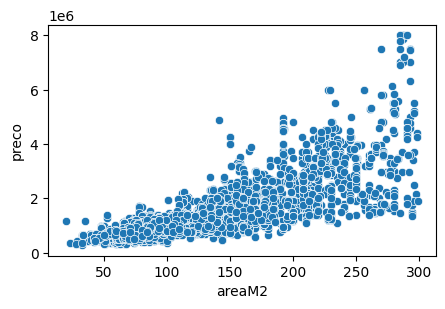

In [ ]:
plt.figure(figsize=(5,3))

sns.scatterplot(x=df.areaM2, y=df.preco)
plt.show()


In [ ]:
np.var(df.preco), np.var(np.log(df.preco))

(1152324795491.0938, 0.33154220111110566)

In [ ]:
np.std(df.preco), np.std(np.log(df.preco))

(1073463.9237026523, 0.5757970138087777)

In [ ]:
df['areaM2_range'] = pd.cut(df['areaM2'], bins=10)
display(df['areaM2_range'].value_counts().sort_index())

,count
areaM2_range,
"(19.721, 47.9]",69
"(47.9, 75.8]",420
"(75.8, 103.7]",734
"(103.7, 131.6]",709
"(131.6, 159.5]",528
"(159.5, 187.4]",448
"(187.4, 215.3]",311
"(215.3, 243.2]",255
"(243.2, 271.1]",165


/tmp/ipykernel_1319/1874268611.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.plot(df.groupby('areaM2_range').preco.var().values)
/tmp/ipykernel_1319/1874268611.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.plot(np.log(df.groupby('areaM2_range').preco.var().values))


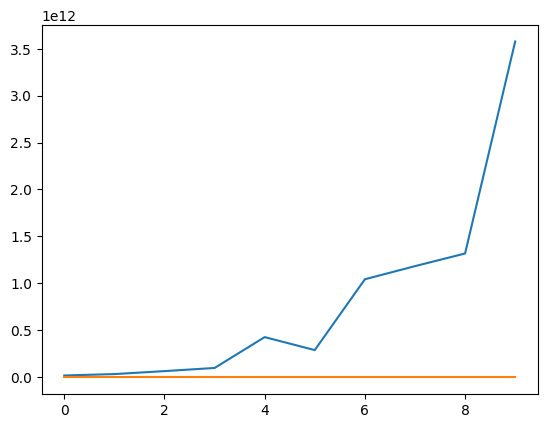

In [ ]:
plt.plot(df.groupby('areaM2_range').preco.var().values)
plt.plot(np.log(df.groupby('areaM2_range').preco.var().values))
plt.show()

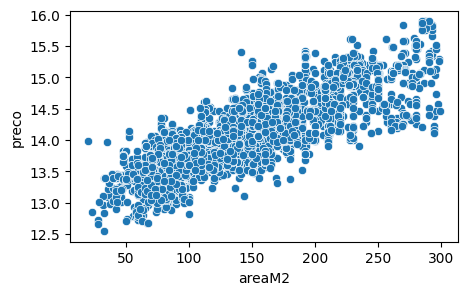

In [ ]:
plt.figure(figsize=(5,3))

sns.scatterplot(x=df.areaM2, y=np.log(df.preco))
plt.show()


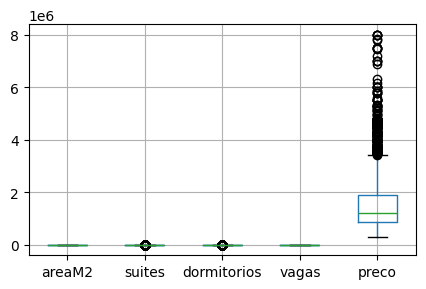

In [ ]:
plt.figure(figsize=(5,3))

df.boxplot(figsize=(10,6))
plt.show()


In [ ]:
lm = sm.ols(formula='preco ~ areaM2 + suites + dormitorios + vagas - 1', data=df)
lm = lm.fit()
print(lm.summary())

preco = lm.predict(df_case)
print()
print(f'Preco estimado: {preco[0]:.2f}')

                                 OLS Regression Results                                
Dep. Variable:                  preco   R-squared (uncentered):                   0.898
Model:                            OLS   Adj. R-squared (uncentered):              0.898
Method:                 Least Squares   F-statistic:                              8233.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):                        0.00
Time:                        15:16:55   Log-Likelihood:                         -55099.
No. Observations:                3741   AIC:                                  1.102e+05
Df Residuals:                    3737   BIC:                                  1.102e+05
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

# Q10.

Construa o mesmo modelo, com os 4 preditores significativos, com o Scikit-learn - com e sem o intercept. Há diferença nos resultados do `statsmodels` e `scikit-learn`?

In [ ]:
X = df[['areaM2', 'suites', 'dormitorios', 'vagas']]
y = df['preco']

model = LinearRegression() # fit_intercept=False) # set fit_intercept to False
model.fit(X, y)

print(model.coef_, model.intercept_, model.score(X, y))

[  10468.46173907  202771.70454038 -311340.86561812  296751.59991048] -3407.312060851371 0.6845689083685004


In [ ]:
lm = sm.ols(formula='preco ~ areaM2 + suites + dormitorios + vagas', data=df)
lm = lm.fit()
print(lm.summary())


                            OLS Regression Results                            
Dep. Variable:                  preco   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     2027.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        18:23:51   Log-Likelihood:                -55099.
No. Observations:                3741   AIC:                         1.102e+05
Df Residuals:                    3736   BIC:                         1.102e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -3407.3121   4.04e+04     -0.084      

In [ ]:
results = pd.DataFrame(lm.params)
results.columns = ['coef_stats']

scikit_coefs_ordered = [model.intercept_] + list(model.coef_)
# scikit_coefs_ordered = list(model.coef_)
results['coef_scikit'] = scikit_coefs_ordered

results.loc['R2','coef_stats'] = lm.rsquared
results.loc['R2','coef_scikit'] = model.score(X, y)

results

,coef_stats,coef_scikit
Intercept,-3407.312061,-3407.312061
areaM2,10468.461739,10468.461739
suites,202771.704540,202771.704540
dormitorios,-311340.865618,-311340.865618
vagas,296751.599910,296751.599910
R2,0.684569,0.684569


# Q11.

Faça o modelo sm.ols incluindo todas as variáveis preditoras, mesmo o bairro que é não numérico, e veja como a api se comporta para criar o modelo. Faça a previsão para o mesmo case considerando o bairro de `vila-mariana`. Observe as variáveis preditoras no summary do modelo. O que aconteceu?

O `statsmodels` faz automaticamente o *hot-encode* das variáveis categóricas.

In [ ]:
df = pd.read_excel('http://meusite.mackenzie.br/rogerio/data_load/regressao_preco_imoveis.xlsx')
df.head()

,bairro,areaM2,suites,dormitorios,banheiros,vagas,preco
0,vila-nova-conceicao,32,1,1,1,1,490000
1,vila-nova-conceicao,157,2,2,2,2,3180000
2,vila-nova-conceicao,205,2,3,3,3,1900000
3,vila-nova-conceicao,193,3,3,3,3,3565000
4,vila-nova-conceicao,116,1,3,2,2,1605000


In [ ]:
df.bairro.value_counts()

,count
bairro,
vila-mariana,1714
paraiso,802
vila-nova-conceicao,789
vila-sonia,307
morumbi,129


In [ ]:
lm = sm.ols(formula='preco ~ bairro + areaM2 + suites + dormitorios + vagas', data=df)
lm = lm.fit()
print(lm.summary())

df_case['bairro'] = 'vila-mariana'

preco = lm.predict(df_case)
print()
print(f'Preco estimado: {preco[0]:.2f}')

                            OLS Regression Results                            
Dep. Variable:                  preco   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     1812.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        18:27:11   Log-Likelihood:                -54290.
No. Observations:                3741   AIC:                         1.086e+05
Df Residuals:                    3732   BIC:                         1.087e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

# Q12.

Aplique agora, ao modelo anterior, o `np.Log()` do preço para reduzir a heterocedasticidade. Exclua ainda os parâmetros não significativos. O resultado é melhor? Altera o valor da predição?

In [ ]:
lm = sm.ols(formula='np.log(preco) ~ bairro + areaM2 + suites + vagas', data=df)
lm = lm.fit()
print(lm.summary())

df_case['bairro'] = 'vila-mariana'

preco = np.exp(lm.predict(df_case))
print()
print(f'Preco estimado: {preco[0]:.2f}')

                            OLS Regression Results                            
Dep. Variable:          np.log(preco)   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     3666.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        18:29:02   Log-Likelihood:                 616.76
No. Observations:                3741   AIC:                            -1218.
Df Residuals:                    3733   BIC:                            -1168.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     